In [20]:
# !pip install usgs-libcomcat
# !pip install basemap
from libcomcat.search import search, get_event_by_id
from libcomcat.dataframes import get_detail_data_frame
from obspy.imaging.beachball import beach
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
from datetime import datetime


In [ ]:

# ---- 1. Define search parameters ----
min_lat, max_lat = 58.5, 60.5     # Example: Southern California
min_lon, max_lon = -154, -150
start_time = datetime(1970,1,1)
end_time = datetime(2025,4,1)
min_mag = 4.0

# ---- 2. Query USGS ComCat ----
events = search(
    starttime=start_time,
    endtime=end_time,
    minlatitude=min_lat,
    maxlatitude=max_lat,
    minlongitude=min_lon,
    maxlongitude=max_lon,
    minmagnitude=min_mag
)
df = get_detail_data_frame(events)

/tmp/ipykernel_3703377/1670436800.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('jet')  # not perceptually uniform colormap!


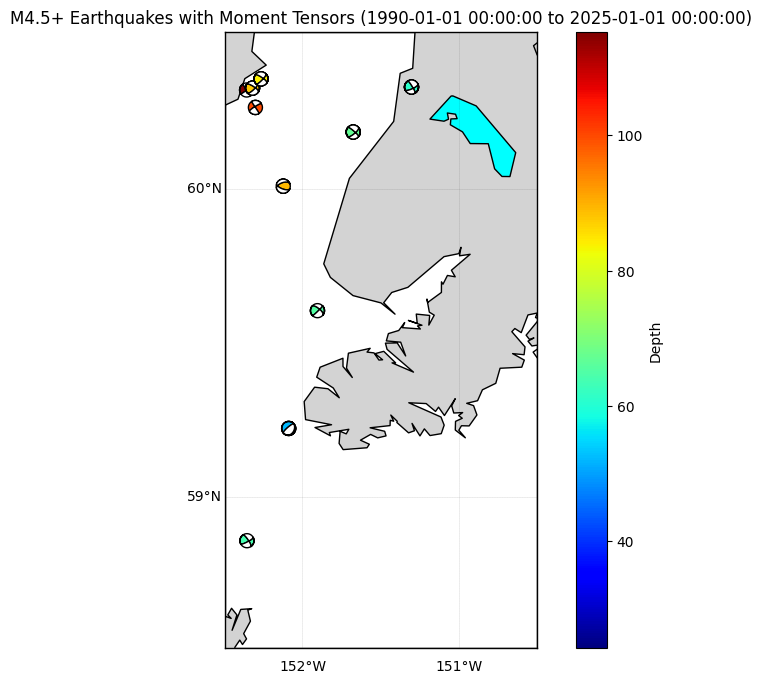

In [94]:
# ---- 3. Set up map ----
fig,ax = plt.subplots(figsize=(10, 8))
m = Basemap(projection='merc',
            llcrnrlat=min_lat, urcrnrlat=max_lat,
            llcrnrlon=min_lon, urcrnrlon=max_lon,
            resolution='i')

m.drawcoastlines()
m.drawcountries()
m.drawstates()
m.drawmapboundary()
m.fillcontinents(color='lightgray', lake_color='aqua')
m.drawparallels(np.arange(-90., 91., 1.), labels=[1,0,0,0], linewidth=0.1)
m.drawmeridians(np.arange(-180., 181., 1.), labels=[0,0,0,1], linewidth=0.1)

# Example: assuming you have a DataFrame `df` with a 'depth' column
depths = df['depth']
norm = mcolors.Normalize(vmin=depths.min(), vmax=depths.max())
cmap = cm.get_cmap('jet')  # not perceptually uniform colormap!

# ---- 4. Loop and plot beach balls ----
for _, row in df.iterrows():
        # fm = np.array((row['ci_np1_strike'],row['ci_np1_dip'],row['ci_np1_rake']))
    fm = np.array((row['us_Mww_np1_strike'],row['us_Mww_np1_dip'],row['us_Mww_np1_rake']))
    color = cmap(norm(row.depth))
    if ~np.isnan(np.sum(fm)):
        x, y = m(row.longitude, row.latitude)
        b = beach(fm, xy=(x, y), width=10000, linewidth=1, facecolor=color)
        b.set_zorder(10)
        plt.gca().add_collection(b)

# Add colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # Dummy mappable for the colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Depth')


plt.title(f"M{min_mag}+ Earthquakes with Moment Tensors ({start_time} to {end_time})")
plt.show()
